In [13]:
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from pydantic import Field, BaseModel
from typing import Optional, Annotated, TypedDict, Literal

In [2]:
load_dotenv()

True

# Non LLM Based Conditional Workflow

In [3]:
class QuadState(TypedDict):
    a: float
    b: float
    c: float

    eq: str
    d: float
    result: str


In [4]:
def find_eq(state: QuadState) -> dict:
    if state["b"] < 0:
        if state["c"] < 0:
            eq = f"{state["a"]}x2 {state["b"]}x {state["c"]}"
        else:
            eq = f"{state["a"]}x2 {state["b"]}x + {state["c"]}"
    else:
        if state["c"] < 0:
            eq = f"{state["a"]}x2 + {state["b"]}x {state["c"]}"
        else:
            eq = f"{state["a"]}x2 + {state["b"]}x + {state["c"]}"
    return {"eq": eq}

In [5]:
def calculate_d(state: QuadState) -> dict:

    d = state["b"]**2 - (4 * state["a"] * state["c"])
    return {"d": d}

In [6]:
def real_roots(state: QuadState) -> dict:

    root1 = (-state["b"] + (state["d"]**0.5))/(2*state["a"])
    root2 = (-state["b"] - (state["d"]**0.5))/(2*state["a"])

    result = f"Roots: {round(root1, 3)} and {round(root2, 3)}"

    return {"result": result}

In [7]:
def one_real_root(state: QuadState) -> dict:

    root = (-state["b"])/(2*state["a"])

    result = f"Roots: {round(root, 3)}"

    return {"result": result}

In [8]:
def no_real_roots(state: QuadState) -> dict:

    result = f"No real roots"

    return {"result": result}

In [9]:
def check_condition(state: QuadState) -> Literal["real_roots", "one_real_root", "no_real_roots"]:
    if state["d"] > 0:
        return "real_roots"
    elif state["d"] == 0:
        return "one_real_root"
    else:
        return "no_real_roots"

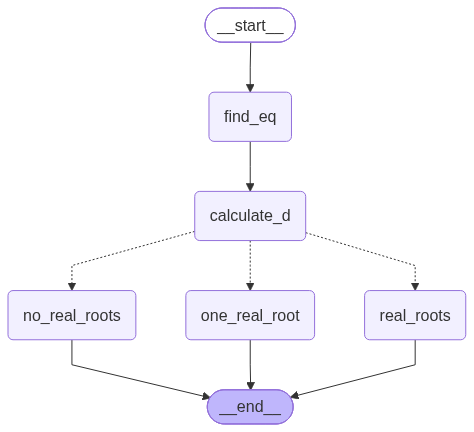

In [10]:
graph = StateGraph(QuadState)

graph.add_node("find_eq", find_eq)
graph.add_node("calculate_d", calculate_d)
graph.add_node("real_roots", real_roots)
graph.add_node("one_real_root", one_real_root)
graph.add_node("no_real_roots", no_real_roots)



graph.add_edge(START, "find_eq")
graph.add_edge("find_eq", "calculate_d")

graph.add_conditional_edges("calculate_d", check_condition)
graph.add_edge("real_roots", END)
graph.add_edge("one_real_root", END)
graph.add_edge("no_real_roots", END)

workflow = graph.compile()
workflow

In [11]:
input_state = {
    "a": 4,
    "b": 2,
    "c": 4
}

output_state = workflow.invoke(input_state)
output_state

{'a': 4,
 'b': 2,
 'c': 4,
 'eq': '4x2 + 2x + 4',
 'd': -60,
 'result': 'No real roots'}

# LLM Based Conditional Workflow

In [52]:
class SentimentState(TypedDict):
    review: str

    sentiment: Literal["positive", "negative", "neutral"]
    diagnosis: dict
    response: str


In [53]:
llm = ChatGroq(
    model="openai/gpt-oss-120b",
    max_tokens=512
)

In [54]:
class LLMSentimentStructuredOutput(BaseModel):
    sentiment: Literal["positive", "neutral", "negative"] = Field(description="Identify the sentiment of the review")

In [55]:
class LLMDiagnosisStructuredOutput(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Others"] =  Field(description="Identify the issue that the user is facing")
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description="The emotional tone expressed by the user")
    urgency: Literal["low", "medium", "high"] = Field(description="How urgent should the issue be resolved")


In [56]:
sentiment_llm = llm.with_structured_output(LLMSentimentStructuredOutput)
diagnosis_llm = llm.with_structured_output(LLMDiagnosisStructuredOutput)

In [57]:
def find_sentiment(state: SentimentState) -> SentimentState:
    prompt = f"For the following review find out the sentiment \n {state["review"]}"

    sentiment_dict = sentiment_llm.invoke(prompt)
    return {"sentiment": sentiment_dict.sentiment}

In [63]:
def check_sentiment(state: SentimentState) -> Literal["run_diagnosis", "positive_response"]:
    if state["sentiment"] == "negative":
        return "run_diagnosis"
    else:
        return "positive_response"

In [64]:
def positive_response(state: SentimentState) -> dict:

    prompt = f"Write a warm thankful message for the review: {state["review"]}. Also kindly ask the user to leave a feedback on our website"

    response = llm.invoke(prompt)
    return {"response": response}

In [65]:
def run_diagnosis(state: SentimentState) -> dict:

    prompt = f"Diagnose the negative review: {state["review"]}"

    response = diagnosis_llm.invoke(prompt)
    return {"diagnosis": response.model_dump()}

In [66]:
def negative_response(state: SentimentState) -> dict:

    prompt = f"""
    The user had this negative review diagnosis:
    Issue type: {state["diagnosis"]["issue_type"]}
    Tone: {state["diagnosis"]["tone"]}
    Urgency: {state["diagnosis"]["urgency"]}

    Provide an empathetic, helpful resolution message
    """

    response = llm.invoke(prompt).content

    return {"response": response}
    

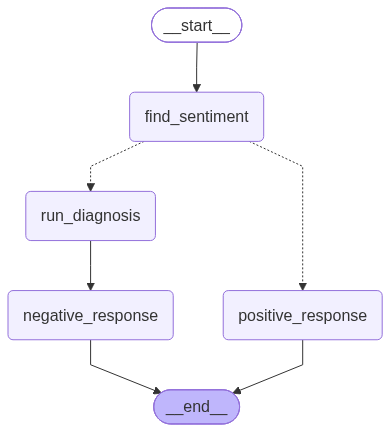

In [67]:
graph = StateGraph(SentimentState)

graph.add_node("find_sentiment", find_sentiment)
graph.add_node("positive_response", positive_response)
graph.add_node("run_diagnosis", run_diagnosis)
graph.add_node("negative_response", negative_response)

graph.add_edge(START, "find_sentiment")
graph.add_conditional_edges("find_sentiment", check_sentiment)

graph.add_edge("positive_response", END)
graph.add_edge("run_diagnosis", "negative_response")
graph.add_edge("negative_response", END)

workflow = graph.compile()
workflow

In [71]:
initial_state={
    'review': "I've been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."
}

output_state = workflow.invoke(initial_state)
output_state


{'review': "I've been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.",
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Bug', 'tone': 'angry', 'urgency': 'high'},
 'response': '**Hi\u202f[Customer Name],**\n\nI’m really sorry to hear about the trouble you’ve experienced – I completely understand how frustrating this must be, especially when you need things to work right away. Thank you for taking the time to let us know; your feedback is incredibly important to us.\n\n**What’s happened?**  \nFrom what you’ve described, it sounds like you’ve run into a bug that’s preventing the product from functioning as expected. I can assure you that this isn’t the experience we want any of our users to have.\n\n**What we’re doing right now**  \n1. **Escalated to our engineering team** – I’ve already flagged this issue as 

In [72]:
print(output_state["response"])

**Hi [Customer Name],**

I’m really sorry to hear about the trouble you’ve experienced – I completely understand how frustrating this must be, especially when you need things to work right away. Thank you for taking the time to let us know; your feedback is incredibly important to us.

**What’s happened?**  
From what you’ve described, it sounds like you’ve run into a bug that’s preventing the product from functioning as expected. I can assure you that this isn’t the experience we want any of our users to have.

**What we’re doing right now**  
1. **Escalated to our engineering team** – I’ve already flagged this issue as *high priority* so they can start investigating immediately.  
2. **Temporary work‑around** – While we work on a fix, you can try the following steps (which have helped other users in similar situations):
   - Clear your browser/app cache and restart the application.  
   - Ensure you’re running the latest version (you can check for updates in the Settings menu).  
   